# 05 · Regresión logística y SVM

Misma partición 80/10/10 del notebook 04. Estos modelos necesitan preparación: imputación con indicador de nulo, escalado y one-hot, todo dentro de un pipeline ajustado solo con `X_train`. Búsqueda de hiperparámetros con `X_val` y evaluación final en `X_test`.

SVM: el lineal se entrena con todos los datos; el de kernel RBF solo con una muestra de 20.000 filas, porque su costo crece con el cuadrado de las filas y con 455.000 no termina.

1. Partición · 2. Pipeline de preparación · 3. Regresión logística · 4. SVM lineal · 5. SVM RBF (muestra) · 6. Comparación en X_test

In [1]:
import warnings, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, precision_recall_curve, average_precision_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200, "display.max_columns", 50)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "processed"

C_BLUE, C_ORANGE, C_AQUA, C_GRAY, C_MUTED = "#2a78d6", "#eb6834", "#1baf7a", "#c9c8c3", "#52514e"
mpl.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": C_GRAY,
                     "axes.grid": True, "grid.color": "#ececea", "axes.axisbelow": True, "axes.titlesize": 13, "axes.titleweight": "bold",
                     "axes.titlelocation": "left", "axes.labelcolor": C_MUTED, "xtick.color": C_MUTED, "ytick.color": C_MUTED})
SEED = 42

## 1. Partición 80/10/10

Idéntica a la del notebook 04 (misma semilla y estratificación), así los resultados son comparables.

In [2]:
train = pd.read_parquet(DATA / "train.parquet")
FEATS = pd.read_csv(DATA / "features_seleccionadas.csv").feature.tolist()
TARGET = "var_rpta_alt"
CAT = [c for c in FEATS if str(train[c].dtype) == "category"]
NUM = [c for c in FEATS if c not in CAT]

X, y = train[FEATS].copy(), train[TARGET]
for c in CAT: X[c] = X[c].astype(str).replace("nan", "NA")
X_train, X_tmp, y_train, y_tmp = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print(f"Variables: {len(FEATS)} = {len(NUM)} numéricas + {len(CAT)} categóricas")
for n, yy in [("X_train", y_train), ("X_val", y_val), ("X_test", y_test)]:
    print(f"{n}: {len(yy):,} filas, tasa de 1 = {yy.mean():.3f}")

Variables: 77 = 62 numéricas + 15 categóricas
X_train: 454,600 filas, tasa de 1 = 0.480
X_val: 56,825 filas, tasa de 1 = 0.480
X_test: 56,826 filas, tasa de 1 = 0.480


## 2. Pipeline de preparación

- Numéricas: imputación por mediana más una columna indicadora de nulo por variable (el nulo tiene significado y así no se pierde), luego escalado estándar.
- Categóricas: one-hot con categorías raras (menos de 500 filas) agrupadas en una sola; las no vistas en train se ignoran.

Se ajusta una sola vez con `X_train` y se reutiliza en todos los modelos.

In [3]:
prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median", add_indicator=True)), ("sc", StandardScaler())]), NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=500, sparse_output=False), CAT),
])
t0 = time.time()
Xt_train = prep.fit_transform(X_train); Xt_val = prep.transform(X_val); Xt_test = prep.transform(X_test)
print(f"Columnas tras la preparación: {Xt_train.shape[1]} (de {len(FEATS)} variables) | {time.time()-t0:.0f} s")

Columnas tras la preparación: 257 (de 77 variables) | 28 s


In [4]:
def mejor_umbral(y_true, s):
    grid = np.quantile(s, np.linspace(0.20, 0.80, 61))
    f1s = [f1_score(y_true, s >= u) for u in grid]
    return float(grid[int(np.argmax(f1s))]), float(max(f1s))

def metricas(y_true, s, umbral):
    pred = (s >= umbral).astype(int)
    return {"AUC": roc_auc_score(y_true, s), "F1": f1_score(y_true, pred), "precisión": precision_score(y_true, pred),
            "recall": recall_score(y_true, pred), "% pred 1": pred.mean()}

def matriz(ax, y_true, pred, titulo):
    cm = confusion_matrix(y_true, pred); ax.imshow(cm, cmap="Blues"); ax.grid(False)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]:,}\n({cm[i, j]/cm.sum():.1%})", ha="center", va="center", fontsize=11, color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_xticklabels(["pred 0", "pred 1"]); ax.set_yticklabels(["real 0", "real 1"]); ax.set_title(titulo)

## 3. Regresión logística

Búsqueda sobre la regularización `C` (menor C = más regularización) con penalización L2. Se puntúa por F1 en `X_val` con el mejor umbral sobre la probabilidad.

In [5]:
res_lr = []
for C in [0.01, 0.1, 1, 10]:
    t0 = time.time()
    m = LogisticRegression(C=C, penalty="l2", solver="lbfgs", max_iter=2000, random_state=SEED)
    m.fit(Xt_train, y_train)
    p = m.predict_proba(Xt_val)[:, 1]; u, f1 = mejor_umbral(y_val, p)
    res_lr.append({"C": C, "AUC_val": roc_auc_score(y_val, p), "F1_val": f1, "umbral": u, "seg": round(time.time() - t0)})
    print(f"C={C:<5} F1_val {f1:.4f} | AUC {res_lr[-1]['AUC_val']:.4f} | {res_lr[-1]['seg']} s")
res_lr = pd.DataFrame(res_lr).sort_values("F1_val", ascending=False).reset_index(drop=True)
C_LR = float(res_lr.iloc[0].C)

lr = LogisticRegression(C=C_LR, penalty="l2", solver="lbfgs", max_iter=2000, random_state=SEED).fit(Xt_train, y_train)
U_LR, _ = mejor_umbral(y_val, lr.predict_proba(Xt_val)[:, 1])
s_test_lr = lr.predict_proba(Xt_test)[:, 1]
print(f"\nMejor C = {C_LR} | umbral {U_LR:.3f} | X_test:", {k: round(v, 4) for k, v in metricas(y_test, s_test_lr, U_LR).items()})

C=0.01  F1_val 0.6900 | AUC 0.7413 | 32 s


C=0.1   F1_val 0.6903 | AUC 0.7415 | 44 s


C=1     F1_val 0.6905 | AUC 0.7415 | 47 s


C=10    F1_val 0.6905 | AUC 0.7415 | 48 s



Mejor C = 10.0 | umbral 0.373 | X_test: {'AUC': 0.7467, 'F1': 0.6954, 'precisión': 0.5989, 'recall': 0.829, '% pred 1': np.float64(0.6644)}


## 4. SVM lineal

`LinearSVC` con todos los datos. No produce probabilidades: el umbral se busca sobre la distancia al hiperplano (`decision_function`). Búsqueda sobre `C`.

In [6]:
res_lsvm = []
for C in [0.01, 0.1, 1]:
    t0 = time.time()
    m = LinearSVC(C=C, dual=False, max_iter=3000, random_state=SEED)
    m.fit(Xt_train, y_train)
    s = m.decision_function(Xt_val); u, f1 = mejor_umbral(y_val, s)
    res_lsvm.append({"C": C, "AUC_val": roc_auc_score(y_val, s), "F1_val": f1, "umbral": u, "seg": round(time.time() - t0)})
    print(f"C={C:<5} F1_val {f1:.4f} | AUC {res_lsvm[-1]['AUC_val']:.4f} | {res_lsvm[-1]['seg']} s")
res_lsvm = pd.DataFrame(res_lsvm).sort_values("F1_val", ascending=False).reset_index(drop=True)
C_LSVM = float(res_lsvm.iloc[0].C)

lsvm = LinearSVC(C=C_LSVM, dual=False, max_iter=3000, random_state=SEED).fit(Xt_train, y_train)
U_LSVM, _ = mejor_umbral(y_val, lsvm.decision_function(Xt_val))
s_test_lsvm = lsvm.decision_function(Xt_test)
print(f"\nMejor C = {C_LSVM} | umbral {U_LSVM:.3f} | X_test:", {k: round(v, 4) for k, v in metricas(y_test, s_test_lsvm, U_LSVM).items()})

C=0.01  F1_val 0.6900 | AUC 0.7410 | 243 s


C=0.1   F1_val 0.6900 | AUC 0.7410 | 589 s


C=1     F1_val 0.6901 | AUC 0.7410 | 987 s



Mejor C = 1.0 | umbral -0.245 | X_test: {'AUC': 0.7461, 'F1': 0.6949, 'precisión': 0.5914, 'recall': 0.8424, '% pred 1': np.float64(0.6838)}


## 5. SVM con kernel RBF sobre una muestra

`SVC(kernel="rbf")` con 20.000 filas estratificadas de `X_train`. Búsqueda pequeña sobre `C` y `gamma`. Se evalúa en `X_val` y `X_test` completos. Es la parte lenta del notebook; se imprime el tiempo de cada ajuste.

In [7]:
N_SUB = 20_000
idx = train_test_split(np.arange(len(y_train)), train_size=N_SUB, stratify=y_train, random_state=SEED)[0]
Xs, ys = Xt_train[idx], y_train.iloc[idx]

res_rbf = []
for C in [0.5, 2]:
    for gamma in ["scale", 0.01]:
        t0 = time.time()
        m = SVC(kernel="rbf", C=C, gamma=gamma, cache_size=2000, random_state=SEED)
        m.fit(Xs, ys)
        s = m.decision_function(Xt_val); u, f1 = mejor_umbral(y_val, s)
        res_rbf.append({"C": C, "gamma": gamma, "n_sv": int(m.n_support_.sum()), "AUC_val": roc_auc_score(y_val, s), "F1_val": f1, "umbral": u, "seg": round(time.time() - t0)})
        print(f"C={C} gamma={gamma:<6} F1_val {f1:.4f} | AUC {res_rbf[-1]['AUC_val']:.4f} | vectores soporte {res_rbf[-1]['n_sv']:,} | {res_rbf[-1]['seg']} s")
res_rbf = pd.DataFrame(res_rbf).sort_values("F1_val", ascending=False).reset_index(drop=True)
b = res_rbf.iloc[0]

rbf = SVC(kernel="rbf", C=float(b.C), gamma=b.gamma if b.gamma == "scale" else float(b.gamma), cache_size=2000, random_state=SEED).fit(Xs, ys)
U_RBF, _ = mejor_umbral(y_val, rbf.decision_function(Xt_val))
s_test_rbf = rbf.decision_function(Xt_test)
print(f"\nMejor C = {b.C}, gamma = {b.gamma} | umbral {U_RBF:.3f} | X_test:", {k: round(v, 4) for k, v in metricas(y_test, s_test_rbf, U_RBF).items()})

C=0.5 gamma=scale  F1_val 0.6918 | AUC 0.7423 | vectores soporte 15,176 | 560 s


C=0.5 gamma=0.01   F1_val 0.6920 | AUC 0.7424 | vectores soporte 15,207 | 451 s


C=2 gamma=scale  F1_val 0.6960 | AUC 0.7471 | vectores soporte 14,875 | 281 s


C=2 gamma=0.01   F1_val 0.6956 | AUC 0.7467 | vectores soporte 14,933 | 219 s



Mejor C = 2.0, gamma = scale | umbral -0.564 | X_test: {'AUC': 0.7503, 'F1': 0.699, 'precisión': 0.6111, 'recall': 0.8164, '% pred 1': np.float64(0.6412)}


## 6. Comparación en X_test

Tres modelos con el umbral fijado en `X_val`. Referencia: LightGBM baseline (notebook 03) dio F1 0,693 en validación temporal; XGBoost y CatBoost están en el notebook 04 sobre esta misma partición.

In [8]:
MODELOS = {"Logística": (s_test_lr, U_LR, C_BLUE), "SVM lineal": (s_test_lsvm, U_LSVM, C_ORANGE), "SVM RBF (20k)": (s_test_rbf, U_RBF, C_AQUA)}
comp = pd.DataFrame({k: metricas(y_test, s, u) for k, (s, u, _) in MODELOS.items()}).T
comp.round(4)

,AUC,F1,precisión,recall,% pred 1
Logística,0.7467,0.6954,0.5989,0.8290,0.6644
SVM lineal,0.7461,0.6949,0.5914,0.8424,0.6838
SVM RBF (20k),0.7503,0.6990,0.6111,0.8164,0.6412


Matrices de confusión en `X_test`. Filas = clase real, columnas = predicción.

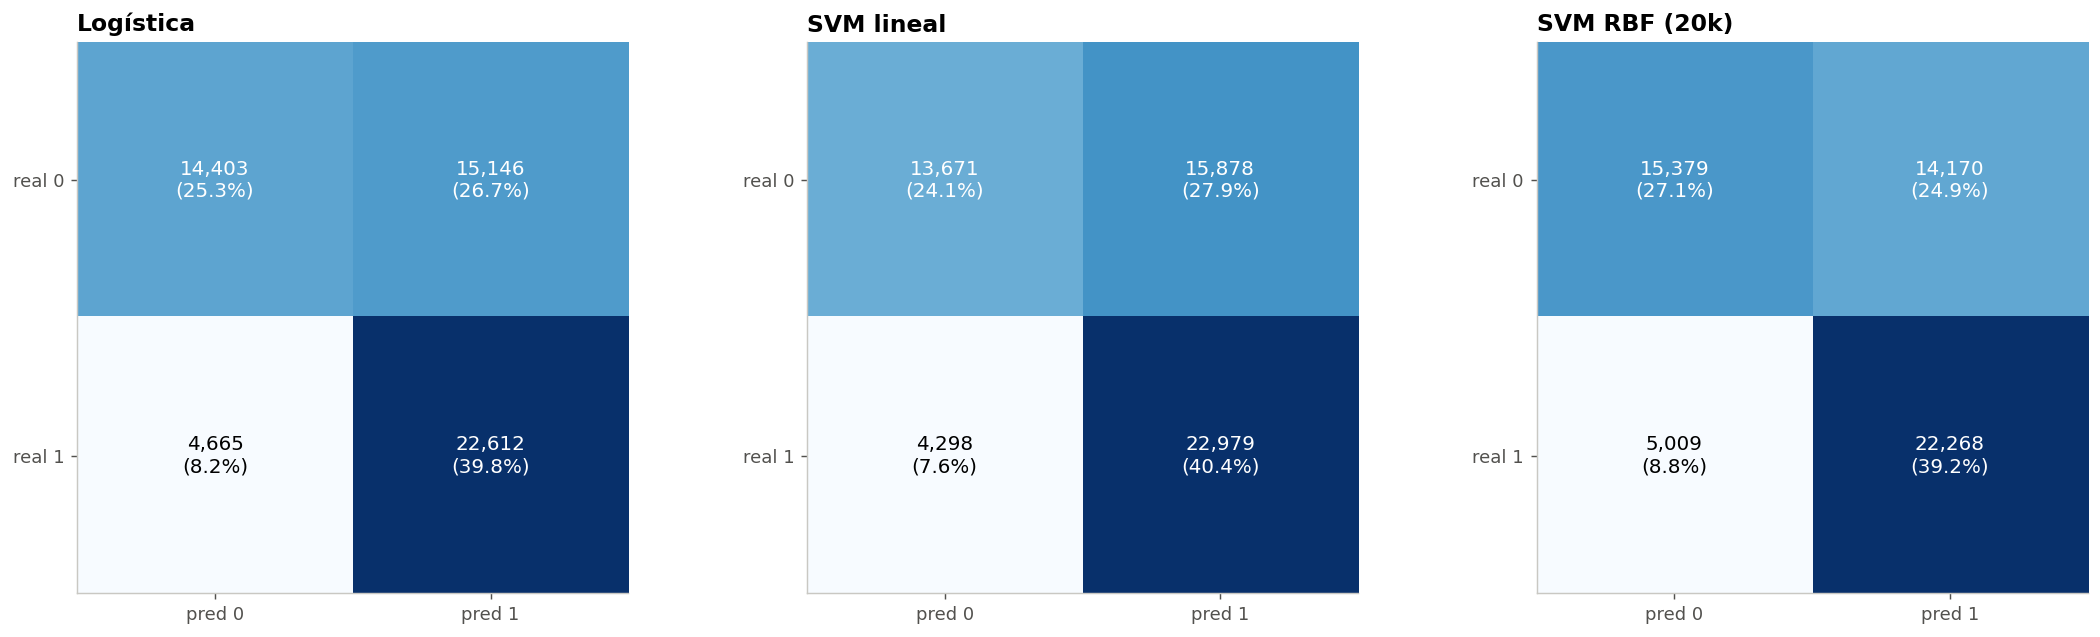

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (k, (s, u, _)) in zip(axes, MODELOS.items()):
    matriz(ax, y_test, (s >= u).astype(int), k)
plt.tight_layout(); plt.show()

Curva precisión-recall en `X_test`. Línea punteada: precisión de un modelo aleatorio. Puntos: umbral elegido de cada modelo.

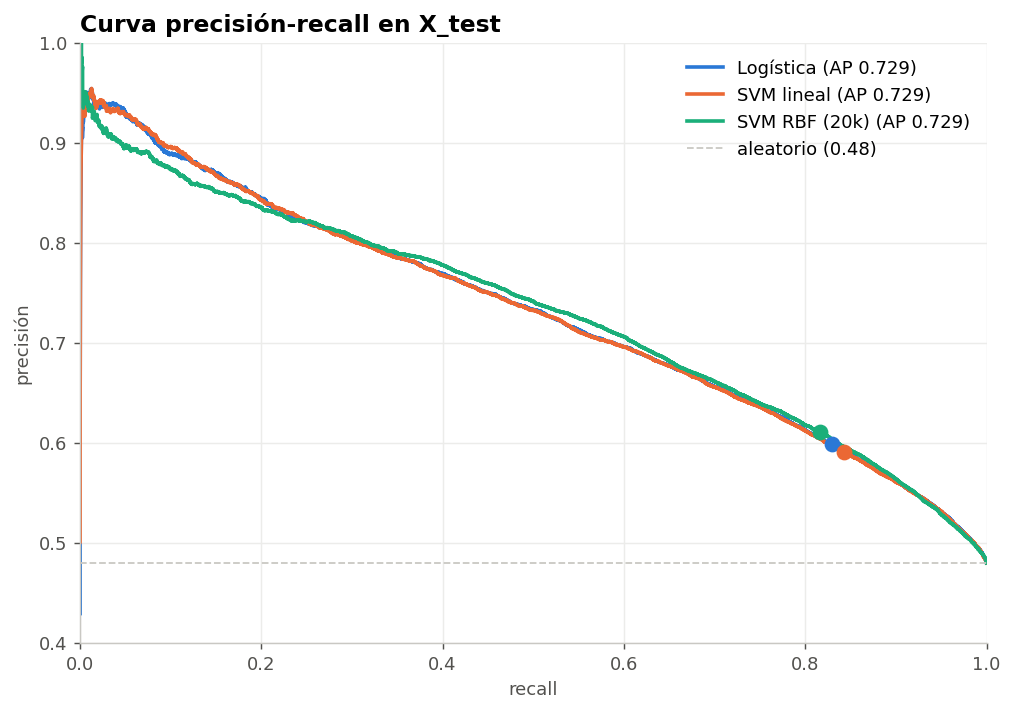

In [10]:
fig, ax = plt.subplots(figsize=(9, 6))
for k, (s, u, col) in MODELOS.items():
    pr, rc, _ = precision_recall_curve(y_test, s)
    ax.plot(rc, pr, color=col, lw=2, label=f"{k} (AP {average_precision_score(y_test, s):.3f})")
    pred = s >= u; ax.scatter([recall_score(y_test, pred)], [precision_score(y_test, pred)], color=col, s=60, zorder=3)
ax.axhline(y_test.mean(), color=C_GRAY, ls="--", lw=1, label=f"aleatorio ({y_test.mean():.2f})")
ax.set_xlabel("recall"); ax.set_ylabel("precisión"); ax.set_xlim(0, 1); ax.set_ylim(0.4, 1); ax.legend(frameon=False); ax.set_title("Curva precisión-recall en X_test")
plt.show()